In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:/Users/91705/Downloads/sales_data_sample.csv", encoding="latin1")

In [123]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [124]:
#The dataset contains 2,823 records and 25 features. 
#It includes sales transactions, customer information, product details, and geographical data that can be used for business analysis.

df.shape   

(2823, 25)

In [125]:
#The dataset contains 25 columns related to orders, products, customers, locations, and sales transactions.

df.columns

Index(['ORDERNUMBER', 'QUANTITYORDERED', 'PRICEEACH', 'ORDERLINENUMBER',
       'SALES', 'ORDERDATE', 'STATUS', 'QTR_ID', 'MONTH_ID', 'YEAR_ID',
       'PRODUCTLINE', 'MSRP', 'PRODUCTCODE', 'CUSTOMERNAME', 'PHONE',
       'ADDRESSLINE1', 'ADDRESSLINE2', 'CITY', 'STATE', 'POSTALCODE',
       'COUNTRY', 'TERRITORY', 'CONTACTLASTNAME', 'CONTACTFIRSTNAME',
       'DEALSIZE'],
      dtype='object')

In [126]:
#This helps us understand:
# Number of rows and columns
# Data type of each column int64 → whole numbers , float64 → decimal numbers.object → text/string 
# Missing values (non-null count)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [127]:
# Missing value analysis was performed using isnull().sum() to identify columns containing null values
#Columns such as ADDRESSLINE2, STATE, and TERRITORY were found to have missing records, while most sales-related fields were complete

df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [128]:
# ADDRESSLINE2 has about 76% missing values.
# Most addresses don't have a second address line.
# We may consider dropping this column later.
# STATE has about 53% missing values.
# Many countries in the dataset don't use states/provinces consistently.
# TERRITORY has about 38% missing values.
# Still contains useful information, so we'll analyze it before deciding what to do.
# Missing value analysis revealed that ADDRESSLINE2 (89.30%), STATE (52.64%), and TERRITORY (38.04%) contained null values. All other columns were complete. 
# These columns were evaluated further during the data cleaning stage

(df.isnull().sum() / len(df)) * 100

ORDERNUMBER          0.000000
QUANTITYORDERED      0.000000
PRICEEACH            0.000000
ORDERLINENUMBER      0.000000
SALES                0.000000
ORDERDATE            0.000000
STATUS               0.000000
QTR_ID               0.000000
MONTH_ID             0.000000
YEAR_ID              0.000000
PRODUCTLINE          0.000000
MSRP                 0.000000
PRODUCTCODE          0.000000
CUSTOMERNAME         0.000000
PHONE                0.000000
ADDRESSLINE1         0.000000
ADDRESSLINE2        89.302161
CITY                 0.000000
STATE               52.639036
POSTALCODE           2.692171
COUNTRY              0.000000
TERRITORY           38.044633
CONTACTLASTNAME      0.000000
CONTACTFIRSTNAME     0.000000
DEALSIZE             0.000000
dtype: float64

In [129]:
# Duplicate record analysis confirmed that the dataset contained no duplicate rows, ensuring data consistency for further analysis.

df.duplicated().sum()

np.int64(0)

In [130]:
df['ORDERDATE'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2823 entries, 0 to 2822
Series name: ORDERDATE
Non-Null Count  Dtype 
--------------  ----- 
2823 non-null   object
dtypes: object(1)
memory usage: 22.2+ KB


In [131]:
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

In [132]:
df['ORDERDATE'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 2823 entries, 0 to 2822
Series name: ORDERDATE
Non-Null Count  Dtype         
--------------  -----         
2823 non-null   datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 22.2 KB


In [133]:
df['Year'] = df['ORDERDATE'].dt.year
df['Month'] = df['ORDERDATE'].dt.month
df['Month_Name'] = df['ORDERDATE'].dt.month_name()
df['Day'] = df['ORDERDATE'].dt.day

In [134]:
df[['ORDERDATE','Year','Month','Month_Name','Day']].head()

,ORDERDATE,Year,Month,Month_Name,Day
0,2003-02-24,2003,2,February,24
1,2003-05-07,2003,5,May,7
2,2003-07-01,2003,7,July,1
3,2003-08-25,2003,8,August,25
4,2003-10-10,2003,10,October,10


In [135]:
# Check ADDRESSLINE2

df['ADDRESSLINE2'].value_counts(dropna = False)

ADDRESSLINE2
NaN            2521
Level 3          55
Suite 400        48
Level 6          46
Level 15         46
2nd Floor        36
Suite 101        25
Suite 750        20
Floor No. 4      16
Suite 200        10
Name: count, dtype: int64

In [136]:
# Check State
df['STATE'].value_counts(dropna=False)

STATE
NaN              1486
CA                416
MA                190
NY                178
NSW                92
Victoria           78
PA                 75
CT                 61
BC                 48
NH                 34
Tokyo              32
NV                 29
Isle of Wight      26
Quebec             22
NJ                 21
Osaka              20
Queensland         15
Name: count, dtype: int64

In [137]:
# Check Territory 

df['TERRITORY'].value_counts(dropna=False)

TERRITORY
EMEA     1407
NaN      1074
APAC      221
Japan     121
Name: count, dtype: int64

In [138]:
# Remove Addressline2

df.drop('ADDRESSLINE2', axis = 1, inplace = True)

In [139]:
df.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
Year                   0
Month                  0
Month_Name             0
Day                    0
dtype: int64

In [140]:
print("Total Sales :",df['SALES'].sum())
print("Average Sales :", df['SALES'].mean())
print("Highest Sales :",df['SALES'].max())
print("Lowest Sales",df['SALES'].min())
print("Sales by Year :", df.groupby('Year')['SALES'].sum())


Total Sales : 10032628.85
Average Sales : 3553.889071909316
Highest Sales : 14082.8
Lowest Sales 482.13
Sales by Year : Year
2003    3516979.54
2004    4724162.60
2005    1791486.71
Name: SALES, dtype: float64


In [141]:
print("Sales by Year :", df.groupby('Month_Name')['SALES'].sum())


Sales by Year : Month_Name
April         669390.96
August        659310.57
December      634679.12
February      810441.90
January       785874.44
July          514875.97
June          454756.78
March         754501.39
May           923972.56
November     2118885.67
October      1121215.22
September     584724.27
Name: SALES, dtype: float64


In [142]:
df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

PRODUCTLINE
Classic Cars        3919615.66
Vintage Cars        1903150.84
Motorcycles         1166388.34
Trucks and Buses    1127789.84
Planes               975003.57
Ships                714437.13
Trains               226243.47
Name: SALES, dtype: float64

In [143]:
print("Top 10 Customer :", df.groupby('CUSTOMERNAME')['SALES'].sum().sort_values(ascending=False).head(10))

Top 10 Customer : CUSTOMERNAME
Euro Shopping Channel           912294.11
Mini Gifts Distributors Ltd.    654858.06
Australian Collectors, Co.      200995.41
Muscle Machine Inc              197736.94
La Rochelle Gifts               180124.90
Dragon Souveniers, Ltd.         172989.68
Land of Toys Inc.               164069.44
The Sharp Gifts Warehouse       160010.27
AV Stores, Co.                  157807.81
Anna's Decorations, Ltd         153996.13
Name: SALES, dtype: float64


In [144]:
print("Sales by Country :", df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False))

Sales by Country : COUNTRY
USA            3627982.83
Spain          1215686.92
France         1110916.52
Australia       630623.10
UK              478880.46
Italy           374674.31
Finland         329581.91
Norway          307463.70
Singapore       288488.41
Denmark         245637.15
Canada          224078.56
Germany         220472.09
Sweden          210014.21
Austria         202062.53
Japan           188167.81
Switzerland     117713.56
Belgium         108412.62
Philippines      94015.73
Ireland          57756.43
Name: SALES, dtype: float64


In [145]:
# Deal size 

df['DEALSIZE'].value_counts()

DEALSIZE
Medium    1384
Small     1282
Large      157
Name: count, dtype: int64

In [146]:
# Order Status Distribution 

df['STATUS'].value_counts()

STATUS
Shipped       2617
Cancelled       60
Resolved        47
On Hold         44
In Process      41
Disputed        14
Name: count, dtype: int64

In [147]:
# Correlation Analysis 

df[['QUANTITYORDERED','PRICEEACH','MSRP','SALES']].corr()

,QUANTITYORDERED,PRICEEACH,MSRP,SALES
QUANTITYORDERED,1.000000,0.005564,0.017881,0.551426
PRICEEACH,0.005564,1.000000,0.670625,0.657841
MSRP,0.017881,0.670625,1.000000,0.635239
SALES,0.551426,0.657841,0.635239,1.000000


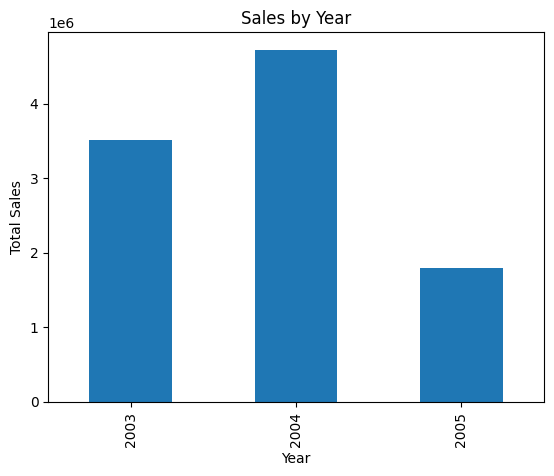

In [148]:
# Sales by Year (Bar Chart)
# Purpose :Shows which year generated the most revenue.

sales_by_year = df.groupby('Year')['SALES'].sum()

sales_by_year.plot(kind='bar')
plt.title('Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show()

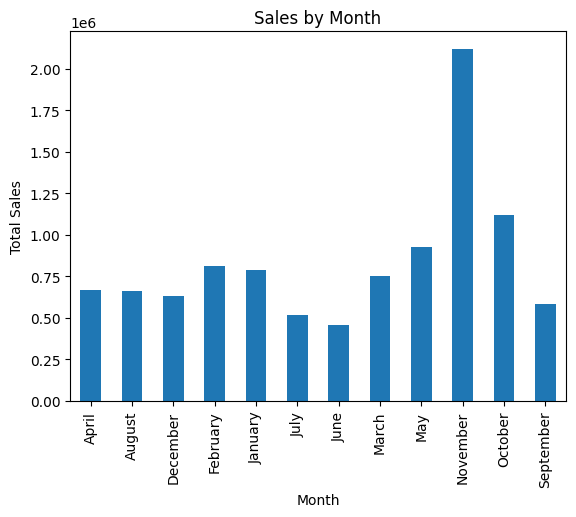

In [149]:
# 2. Sales by Month (Bar Chart)
# Purpose : Identifies seasonal sales patterns.

sales_by_month = df.groupby('Month_Name')['SALES'].sum()

sales_by_month.plot(kind='bar')
plt.title('Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

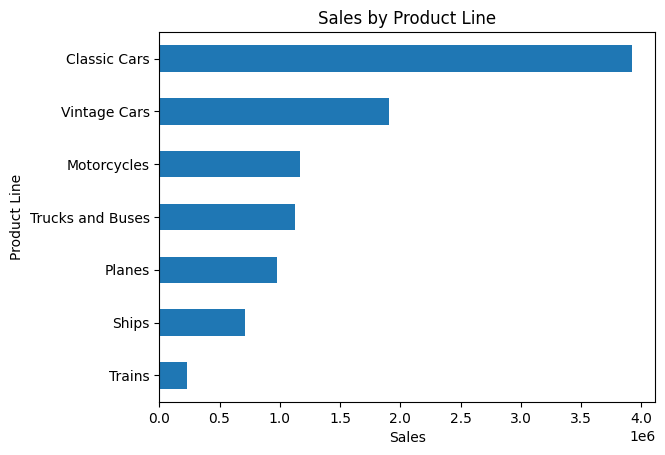

In [150]:
# Sales by Product Line (Bar Chart)
# Purpose : Shows best-selling product categories.

sales_product = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values()

sales_product.plot(kind='barh')
plt.title('Sales by Product Line')
plt.xlabel('Sales')
plt.ylabel('Product Line')
plt.show()

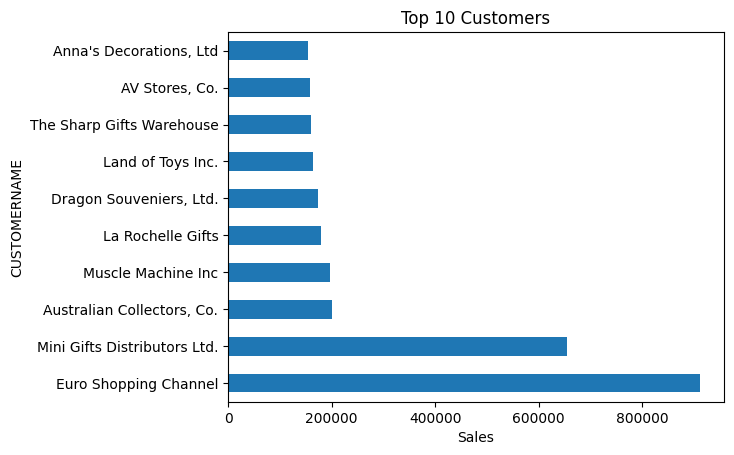

In [151]:
# Top 10 Customers (Horizontal Bar Chart)
# Purpose :Finds major revenue contributors.

top_customers = (
    df.groupby('CUSTOMERNAME')['SALES']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind='barh')
plt.title('Top 10 Customers')
plt.xlabel('Sales')
plt.show()

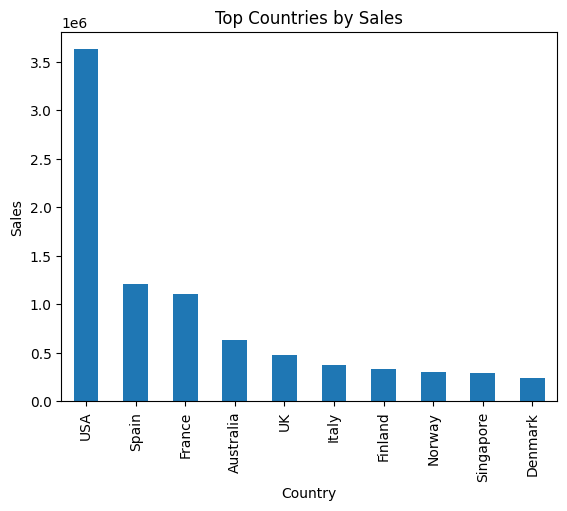

In [152]:
# Top 10 Countries by Sales
# Purpose : Shows strongest markets.

top_countries = (
    df.groupby('COUNTRY')['SALES']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries.plot(kind='bar')
plt.title('Top Countries by Sales')
plt.xlabel('Country')
plt.ylabel('Sales')
plt.show()

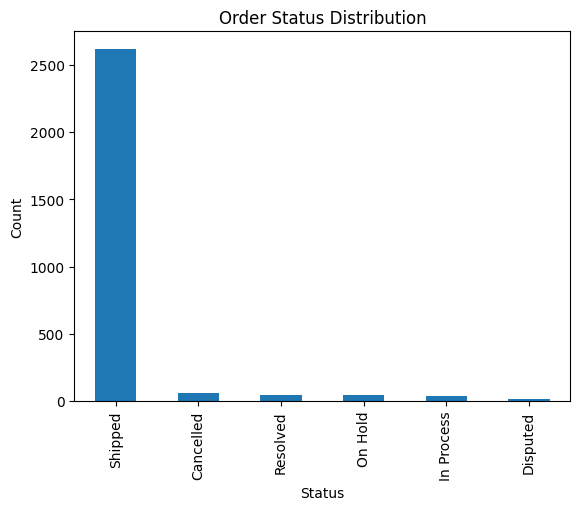

In [153]:
# Order Status Distribution
# Purpose: Measures operational performance

df['STATUS'].value_counts().plot(kind='bar')

plt.title('Order Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

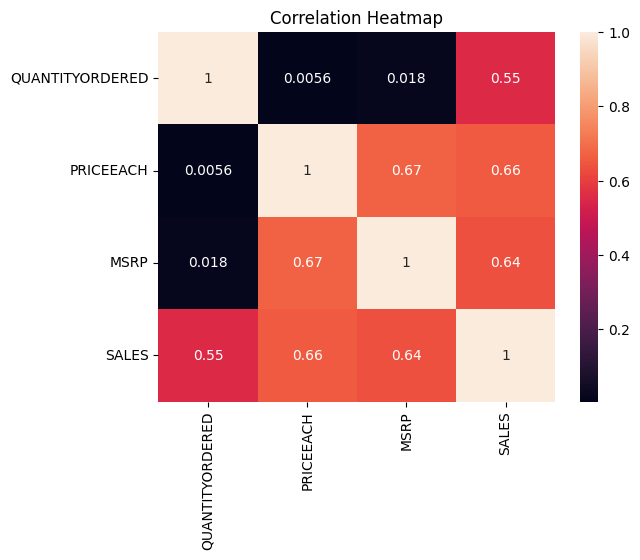

In [154]:
# Correlation Heatmap
# Purpose :Shows relationships between numerical variables.

corr = df[['QUANTITYORDERED','PRICEEACH','MSRP','SALES']].corr()

sns.heatmap(corr, annot=True)

plt.title('Correlation Heatmap')
plt.show()

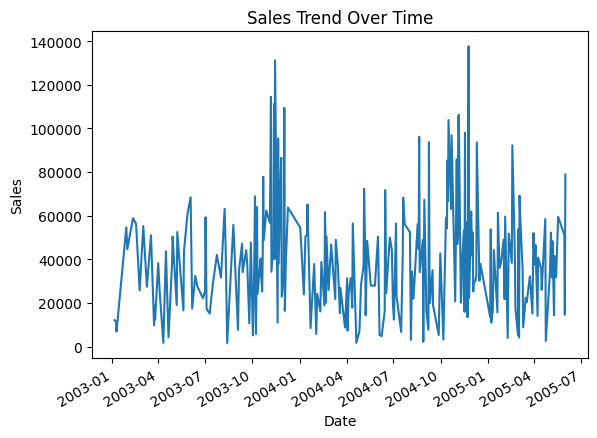

In [155]:
# Sales Trend Over Time (Line Chart)
# Purpose :Shows business growth over time.

monthly_sales = df.groupby('ORDERDATE')['SALES'].sum()

monthly_sales.plot()

plt.title('Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [156]:
df.to_csv("sales_cleaned.csv", index=False)

In [157]:
df.shape

(2823, 28)